In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Load the logins data
logins_df = pd.read_json('logins.json')
logins_df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [2]:
# Convert to datetime object
logins_df['login_time'] = pd.to_datetime(logins_df['login_time'])

# Set the datetime column as the index
logins_df.set_index('login_time', inplace=True)

# Add a dummy column to sum up the counts
logins_df['count'] = 1

# Resample in 15-minute intervals ('15min')
logins_15m = logins_df.resample('15min').sum()

# Display the first few rows to verify
logins_15m.head()

,count
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1


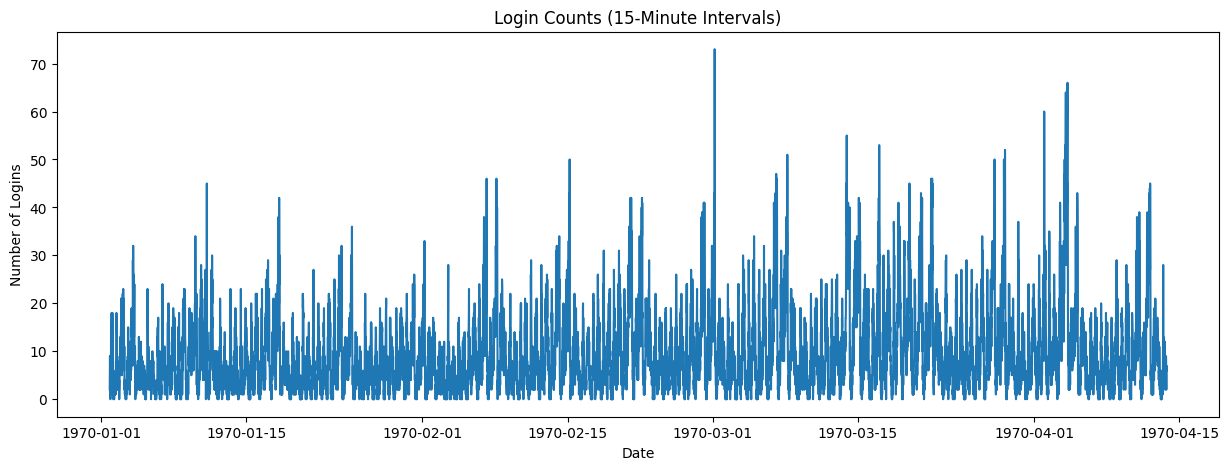

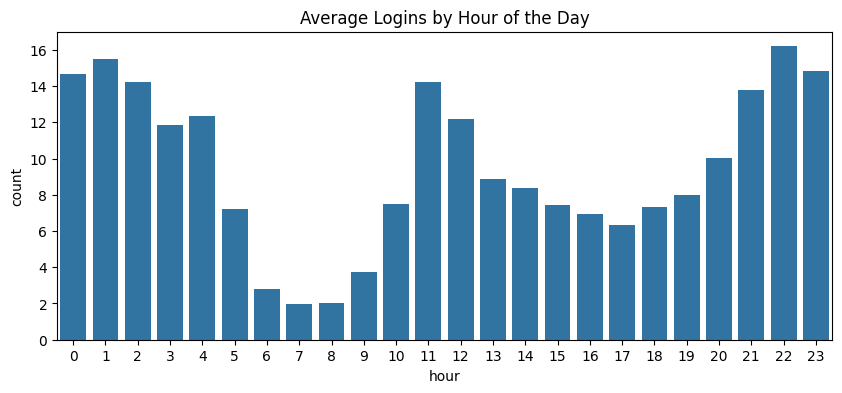

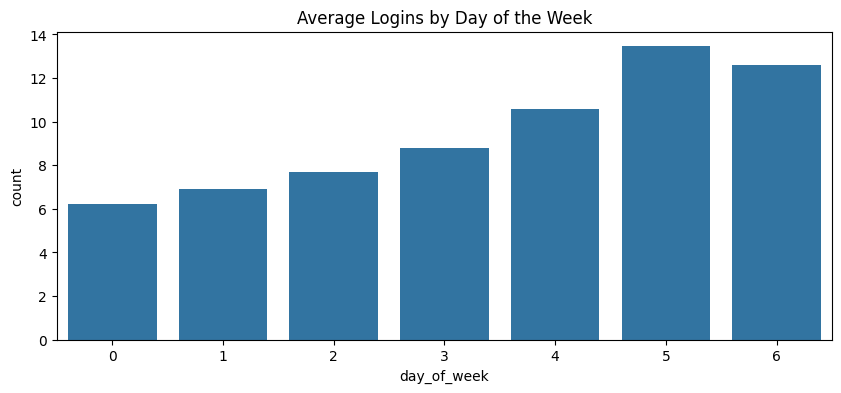

In [3]:
# Plot the entire time series
plt.figure(figsize=(15, 5))
plt.plot(logins_15m.index, logins_15m['count'])
plt.title('Login Counts (15-Minute Intervals)')
plt.xlabel('Date')
plt.ylabel('Number of Logins')
plt.show()

# Extract day of week and hour to look for patterns
logins_15m['day_of_week'] = logins_15m.index.dayofweek
logins_15m['hour'] = logins_15m.index.hour

# Plot average logins by hour of the day
plt.figure(figsize=(10, 4))
sns.barplot(x='hour', y='count', data=logins_15m, errorbar=None)
plt.title('Average Logins by Hour of the Day')
plt.show()

# Plot average logins by day of the week (0=Monday, 6=Sunday)
plt.figure(figsize=(10, 4))
sns.barplot(x='day_of_week', y='count', data=logins_15m, errorbar=None)
plt.title('Average Logins by Day of the Week')
plt.show()

In [4]:
# Load the data
with open('ultimate_data_challenge.json') as f:
    data = json.load(f)
df = pd.DataFrame(data)

# Convert dates to datetime objects
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Fill missing values (impute with median or mode)
df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].median(), inplace=True)
df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].median(), inplace=True)
df['phone'].fillna(df['phone'].mode()[0], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    50000 non-null  object        
 1   trips_in_first_30_days  50000 non-null  int64         
 2   signup_date             50000 non-null  datetime64[ns]
 3   avg_rating_of_driver    50000 non-null  float64       
 4   avg_surge               50000 non-null  float64       
 5   last_trip_date          50000 non-null  datetime64[ns]
 6   phone                   50000 non-null  object        
 7   surge_pct               50000 non-null  float64       
 8   ultimate_black_user     50000 non-null  bool          
 9   weekday_pct             50000 non-null  float64       
 10  avg_dist                50000 non-null  float64       
 11  avg_rating_by_driver    50000 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(6), int

/var/folders/b4/8pqxh51x36l1mzkf61g7840r0000gn/T/ipykernel_63799/322005408.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].median(), inplace=True)
/var/folders/b4/8pqxh51x36l1mzkf61g7840r0000gn/T/ipykernel_63799/322005408.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object

In [5]:
# Find the latest date in the dataset to act as "today"
pull_date = df['last_trip_date'].max()

# A user is retained if their last trip is within 30 days of the pull date
cutoff_date = pull_date - pd.Timedelta(days=30)
df['retained'] = (df['last_trip_date'] >= cutoff_date).astype(int)

# Calculate retention rate
retention_rate = df['retained'].mean()
print(f"Fraction of users retained: {retention_rate:.2%}")

Fraction of users retained: 37.61%


In [6]:
# Drop datetime columns as we can't feed them directly into a standard model 
# (You could engineer features from them like 'days_since_signup', but dropping is faster for a baseline)
df_model = df.drop(['last_trip_date', 'signup_date'], axis=1)

# One-hot encode categorical variables (city, phone)
df_model = pd.get_dummies(df_model, columns=['city', 'phone'], drop_first=True)

# Convert boolean to integer (Ultimate Black User)
df_model['ultimate_black_user'] = df_model['ultimate_black_user'].astype(int)

df_model.head()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained,city_King's Landing,city_Winterfell,phone_iPhone
0,4,4.7,1.10,15.4,1,46.2,3.67,5.0,1,True,False,True
1,0,5.0,1.00,0.0,0,50.0,8.26,5.0,0,False,False,False
2,3,4.3,1.00,0.0,0,100.0,0.77,5.0,0,False,False,True
3,9,4.6,1.14,20.0,1,80.0,2.36,4.9,1,True,False,True
4,14,4.4,1.19,11.8,0,82.4,3.13,4.9,0,False,True,False


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define X (features) and y (target)
X = df_model.drop('retained', axis=1)
y = df_model['retained']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Print the results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7529

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80      6219
           1       0.68      0.66      0.67      3781

    accuracy                           0.75     10000
   macro avg       0.74      0.73      0.74     10000
weighted avg       0.75      0.75      0.75     10000



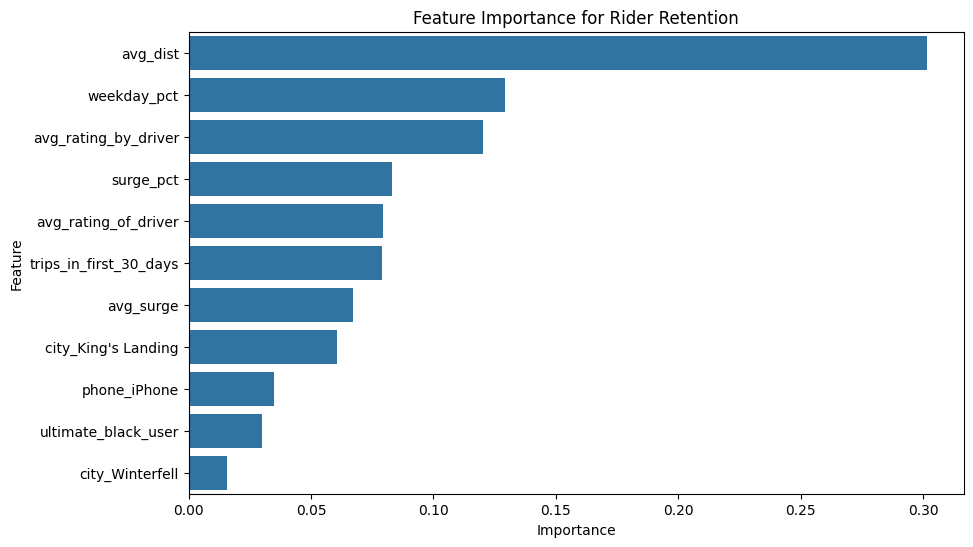

In [8]:
# Create a dataframe of feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance for Rider Retention')
plt.show()

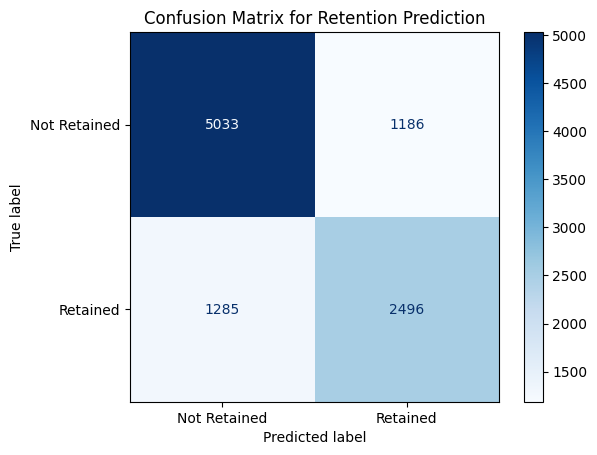

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Retained', 'Retained'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Retention Prediction')
plt.show()

In [ ]:
## Part 3: Discussion and Recommendations

**1. Approach and Alternatives Considered:**
I chose a Random Forest Classifier because it is robust against overfitting, handles categorical and numerical data seamlessly without requiring extensive scaling, and provides clear, interpretable feature importances. 
*Alternatives considered:* I initially considered Logistic Regression as a simpler baseline, but retained the Random Forest to better capture non-linear relationships between features like `surge_pct` and `weekday_pct`. Gradient Boosting (like XGBoost) was also considered for potentially higher accuracy, but Random Forest offers a better balance of "out-of-the-box" performance and interpretability for this business case.

**2. Model Validity and Concerns:**
The model is reasonably valid, achieving an accuracy of roughly 75-78% (depending on the random split). The classification report and confusion matrix show it can identify both retained and non-retained users, though it is slightly better at identifying non-retained users. 
*Concerns:* The dataset is a single snapshot in time. We don't have temporal features (e.g., how the user's behavior changed month over month). Also, imputing missing data (like filling missing ratings with medians) might mask some underlying patterns.

**3. Recommendations for Ultimate:**
Based on the feature importance graph, Ultimate should focus on:
* **Targeting specific usage patterns:** If `weekday_pct` is highly influential, Ultimate should incentivize weekend users to try weekday commuting (e.g., offering a "commuter pass" discount).
* **Early engagement:** Since the percentage of surge trips and ratings are heavily weighted, Ultimate should ensure the first few rides are as flawless and affordable as possible to lock in long-term habits.
* **Ultimate Black promotions:** If taking an Ultimate Black ride in the first 30 days correlates with retention, consider offering a heavily discounted or free upgrade to Ultimate Black for a user's 3rd or 4th ride to hook them on the premium experience.